In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random

import matplotlib.pyplot as plt

import os
import sys

random.seed(0)
pair_seed = 420

module_path = os.path.abspath(".")
if module_path not in sys.path:
    sys.path.append(module_path)

dtype = torch.float32

############## Use GPU ##############
USE_GPU = True
#####################################
if USE_GPU == True and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('using device:', device)

using device: cpu


# Creating the data
We want the input to be a list of pairs which are turned into one-hot encoders. These are all possible combinations of integers. Then we want the output to be the sum mod p. That is just an array of the same length as the number of pairs.

In [7]:
def data_create(p: int, frac: float, device, pair_seed: int | None = None):
    X_pairs = torch.cartesian_prod(
        torch.arange(p, device=device),
        torch.arange(p, device=device)
    )
    Y = (X_pairs[:, 0] + X_pairs[:, 1]) % p
    X = F.one_hot(X_pairs, num_classes=p).float()

    n = X.shape[0]
    n_train = int(frac * n)

    if pair_seed is None:
        perm = torch.randperm(n, device=device)
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed)
        perm = torch.randperm(n, generator=g, device=device)

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    return {
        "X_pairs": X_pairs,
        "Y": Y,
        "X_train": X[train_idx],
        "Y_train": Y[train_idx],
        "X_test": X[test_idx],
        "Y_test": Y[test_idx],
        "pairs_train": X_pairs[train_idx],
        "pairs_test": X_pairs[test_idx],
    }


In [19]:
dat=data_create(97, 0.3, device, pair_seed)
print(dat['Y'].shape)
print(dat['X_train'].shape)

torch.Size([9409])
torch.Size([2822, 2, 97])


# MLP class definition
Below I just define a class that has a 2-layer MLP and performs the required forward pass

In [3]:
class MLP(nn.Module):
    def __init__(self, in_size, hid_size, out_size):
        super(MLP, self).__init__()

        self.in_size=in_size
        self.hid_size=hid_size
        self.out_size=out_size
        self.fc1=nn.Linear(in_size, hid_size, bias=False)
        self.fc2=nn.Linear(hid_size, out_size, bias=False)
        
        torch.nn.init.normal_(self.fc1.weight, mean=0.0, std=0.25**0.5 / np.power(2*self.hid_size, 1/3)) #### standard initialization
        torch.nn.init.normal_(self.fc2.weight, mean=0.0, std=0.25**0.5 / np.power(2*self.hid_size, 1/3))

    def forward(self, x):
        x = x.flatten(1)
        x = self.fc2( F.relu(  self.fc1(x)  ) )
        return x


# Define loss function and criterion

In [ ]:
p = 97
frac = 0.3
hid_size = 512
n_epochs = 30000

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

data = data_create(p, frac, device, pair_seed=420)

model = MLP(in_size=2*p, hid_size=hid_size, out_size=p).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.5) #large weight decay is crucial as the grok time is inverse proportional to it and otherwise we would not see it


In [10]:
train_losses = torch.empty(n_epochs, device=device)
test_losses = torch.empty(n_epochs, device=device)
train_accs = torch.empty(n_epochs, device=device)
test_accs = torch.empty(n_epochs, device=device)

data=data_create(p,frac,device)
X_train=data['X_train'].float()
Y_train=data['Y_train']
X_test=data['X_test'].float()
Y_test=data['Y_test']

for epoch in range(n_epochs):
    model.train()

    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, Y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        train_logits = model(X_train)
        test_logits = model(X_test)

        train_loss = criterion(train_logits, Y_train)
        test_loss = criterion(test_logits, Y_test)

        train_pred = train_logits.argmax(dim=1)
        test_pred = test_logits.argmax(dim=1)

        train_acc = (train_pred == Y_train).float().mean()
        test_acc = (test_pred == Y_test).float().mean()

    train_losses[epoch] = train_loss
    test_losses[epoch] = test_loss
    train_accs[epoch] = train_acc
    test_accs[epoch] = test_acc

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch+1:6d}/{n_epochs} | "
            f"train_loss={train_loss.item():.6f} | "
            f"test_loss={test_loss.item():.6f} | "
            f"train_acc={train_acc.item():.6f} | "
            f"test_acc={test_acc.item():.6f}"
        )

Epoch    500/30000 | train_loss=0.066821 | test_loss=9.048276 | train_acc=1.000000 | test_acc=0.000000
Epoch   1000/30000 | train_loss=0.029128 | test_loss=8.998346 | train_acc=1.000000 | test_acc=0.000000
Epoch   1500/30000 | train_loss=0.018500 | test_loss=8.806506 | train_acc=1.000000 | test_acc=0.000000
Epoch   2000/30000 | train_loss=0.012730 | test_loss=8.617421 | train_acc=1.000000 | test_acc=0.000000
Epoch   2500/30000 | train_loss=0.009079 | test_loss=8.405502 | train_acc=1.000000 | test_acc=0.000000
Epoch   3000/30000 | train_loss=0.006609 | test_loss=8.162338 | train_acc=1.000000 | test_acc=0.000000
Epoch   3500/30000 | train_loss=0.004882 | test_loss=7.877114 | train_acc=1.000000 | test_acc=0.000000
Epoch   4000/30000 | train_loss=0.003653 | test_loss=7.567872 | train_acc=1.000000 | test_acc=0.000000
Epoch   4500/30000 | train_loss=0.002754 | test_loss=7.233479 | train_acc=1.000000 | test_acc=0.000607
Epoch   5000/30000 | train_loss=0.002089 | test_loss=6.873033 | train_acc

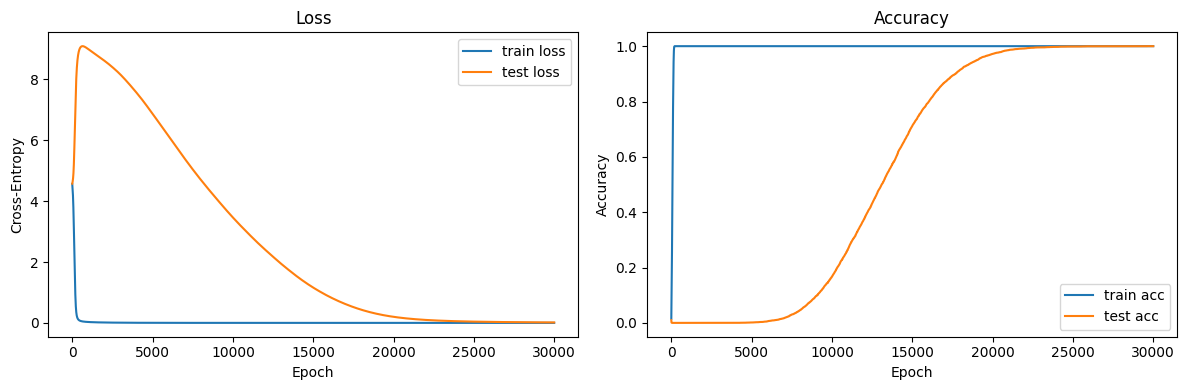

In [11]:
epochs_cpu = torch.arange(len(train_losses)).cpu()
train_losses_cpu = train_losses.detach().cpu()
test_losses_cpu = test_losses.detach().cpu()
train_accs_cpu = train_accs.detach().cpu()
test_accs_cpu = test_accs.detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_cpu, train_losses_cpu, label="train loss")
axes[0].plot(epochs_cpu, test_losses_cpu, label="test loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

axes[1].plot(epochs_cpu, train_accs_cpu, label="train acc")
axes[1].plot(epochs_cpu, test_accs_cpu, label="test acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


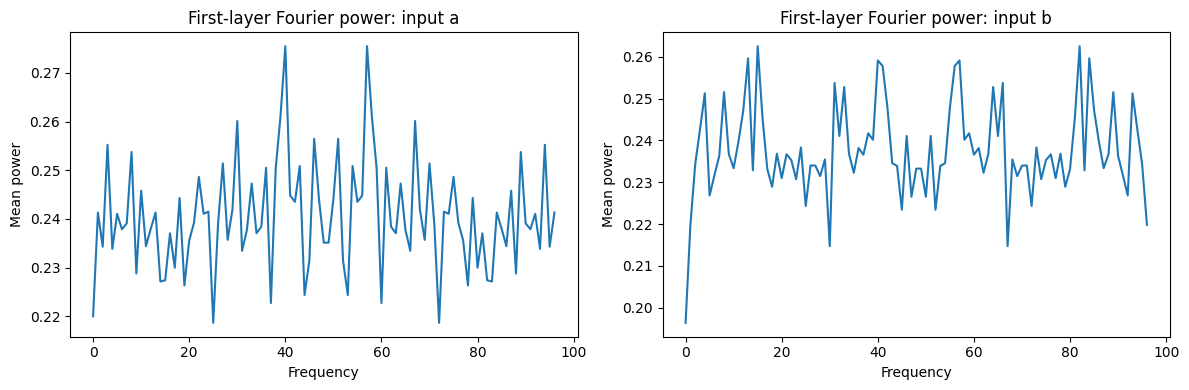

In [14]:
W1 = model.fc1.weight.detach().cpu()          # shape: (hid_size, 2*p)
Wa = W1[:, :p]                                # weights on first input
Wb = W1[:, p:]                                # weights on second input

Fa = torch.fft.fft(Wa, dim=1)                 # shape: (hid_size, p)
Fb = torch.fft.fft(Wb, dim=1)

power_a = (Fa.abs() ** 2).mean(dim=0)
power_b = (Fb.abs() ** 2).mean(dim=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(power_a.numpy())
axes[0].set_title("First-layer Fourier power: input a")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Mean power")

axes[1].plot(power_b.numpy())
axes[1].set_title("First-layer Fourier power: input b")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Mean power")

plt.tight_layout()
plt.show()


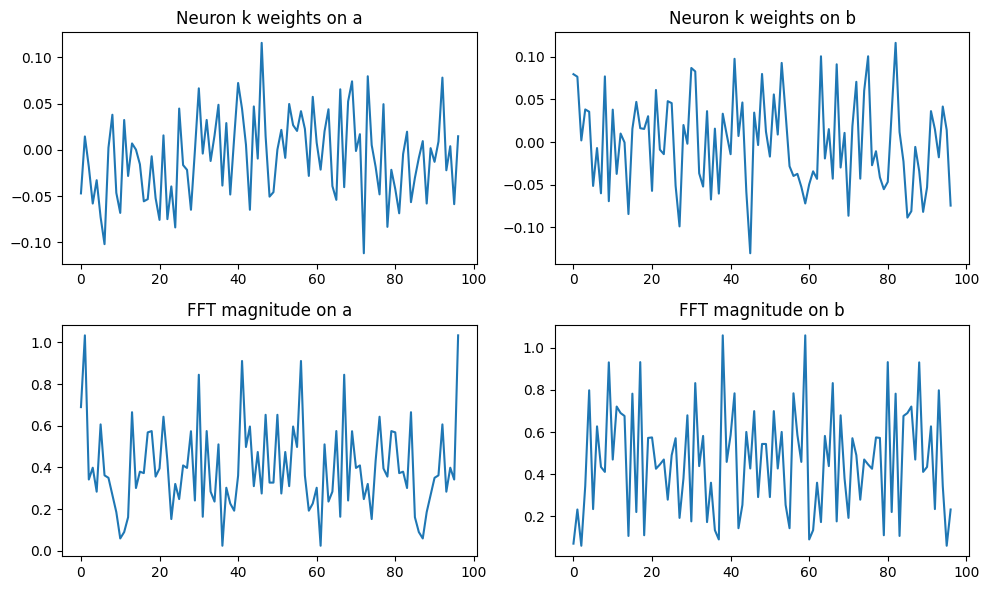

In [17]:
k = 33

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0, 0].plot(Wa[k].numpy())
axes[0, 0].set_title("Neuron k weights on a")

axes[0, 1].plot(Wb[k].numpy())
axes[0, 1].set_title("Neuron k weights on b")

axes[1, 0].plot(Fa[k].abs().numpy())
axes[1, 0].set_title("FFT magnitude on a")

axes[1, 1].plot(Fb[k].abs().numpy())
axes[1, 1].set_title("FFT magnitude on b")

plt.tight_layout()
plt.show()


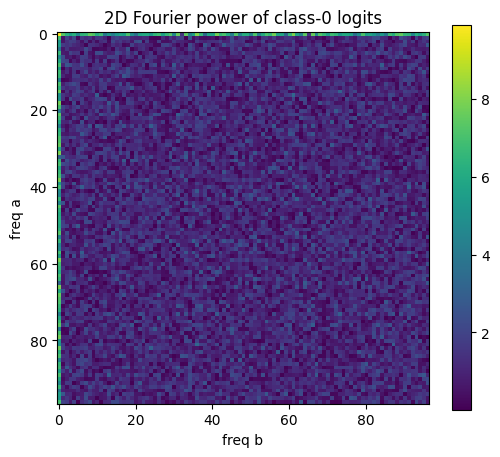

In [16]:
with torch.no_grad():
    X_pairs = torch.cartesian_prod(torch.arange(p, device=device), torch.arange(p, device=device))
    X_full = F.one_hot(X_pairs, num_classes=p).float()
    logits = model(X_full).cpu()              # shape: (p*p, p)

logit_c = logits[:, 0].reshape(p, p)          # class-0 logit over the grid
F2 = torch.fft.fft2(logit_c)
power2 = (F2.abs() ** 2)

plt.figure(figsize=(6, 5))
plt.imshow(torch.log1p(power2).numpy(), cmap="viridis")
plt.colorbar()
plt.title("2D Fourier power of class-0 logits")
plt.xlabel("freq b")
plt.ylabel("freq a")
plt.show()


# To do $S_5$ we need:
* a function that generates the permutations
* a function that computes the multiplication
* mlp with 1 hidden layer and two embeddings

In [2]:
from sympy.combinatorics.named_groups import SymmetricGroup as SymPySymmetricGroup
from sympy.combinatorics import Permutation, PermutationGroup
import math

class symmgr():
    def __init__(self, n:int, device):
        self.g=SymPySymmetricGroup(n)
        self.n = n
        
        self.device=device
        self.elements = list(self.g.generate_schreier_sims())
        self.order = len(self.elements)
        self.multiplication_table = self.compute_multiplication_table()
        #elements in g are stored in .elements; elements is an array of n! indices, each index labelling one permutation, which is an n-array
        #when we embed later in the MLP, we will embed indices, not permutations themselves. 
        #multiplication table takes 2 indices 


        self.identity = [i for i in range(self.order) if self.idx_to_perm(i).order() == 1][0] #compute the index of the identity, which might not be 0

    def idx_to_perm(self, x):
        #convert index of a permutation to the array
        return self.elements[x]
    
    def perm_to_idx(self,perm):
        #convert perm to the index
        return self.elements.index(perm)
    
    def compute_signatures(self, x):
        #given an index 'x', compute the signature of that permutation having index x
        return self.idx_to_perm(x).signature()
    
    def compute_inverses(self, x):
        #given an index 'x', compute the index of the inverse permutation
        return (self.multiplication_table[x, :] == self.identity).nonzero().item()
    
    def compose(self, x, y):
        #take two indices and return the index of the permutation which lies in the composition
        return self.perm_to_idx(self.idx_to_perm(x) * self.idx_to_perm(y))
    
    def square_times(self, a, b):
        a2 = self.multiplication_table[a, a].item()
        return self.multiplication_table[a2, b].item()
    
    def aba(self, a,b):
        return self.compose(self.compose(a,b),a)
    
    def compute_multiplication_table(self):
        #this gives for (i,j) indices the index of the composed permutation
        table = torch.zeros((self.order, self.order), dtype=torch.int64, device=self.device)
        for i in range(self.order):
            for j in range(self.order):
                table[i, j] = self.compose(i, j)
        return table
    

In [21]:
# I want my data to be embedded as ((n!)^2,2) and ((n!)^2) vectors
def data_create_sym(n: int, frac: float, device, pair_seed: int | None = None):
    grp=symmgr(n, device)
    
    idx=torch.arange(grp.order,device=device)
    X=torch.cartesian_prod(idx,idx)
    Y = torch.tensor([grp.compose(i.item(), j.item()) for i, j in X],device=device)



    if pair_seed is None:
        perm = torch.randperm(grp.order*grp.order, device=device)
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed)
        perm = torch.randperm(grp.order*grp.order, generator=g, device=device)

    N=X.shape[0]
    N_train=int(frac*N)

    train_idx=perm[:N_train]
    test_idx=perm[N_train:]

    return {'X': X[perm], 'Y': Y[perm], 'X_train': X[train_idx], 'Y_train': Y[train_idx], 'X_test': X[test_idx], 'Y_test': Y[test_idx], 'grp':grp}   
    

The order of the permutations is reversed. If $p(i)$ is the first row and $q(i)$ is the second, the multiplication is $q(p(i))$

In [22]:
dic=data_create_sym(3, 0.3, device, pair_seed)
print(dic['X'][9])
print(dic['Y'][9])
print(dic['grp'].idx_to_perm(dic['X'][9,0].item()).array_form)
print(dic['grp'].idx_to_perm(dic['X'][9,1].item()).array_form)
print(dic['grp'].idx_to_perm(dic['Y'][9].item()).array_form)

tensor([2, 1], device='cuda:0')
tensor(0, device='cuda:0')
[2, 0, 1]
[1, 2, 0]
[0, 1, 2]


In [23]:
class PermMLP(nn.Module):
    def __init__(self, in_size, embed_size, hid_size, out_size):
        super(PermMLP,self).__init__()

        self.in_size=in_size
        self.out_size=out_size
        self.hid_size=hid_size
        self.embed_size=embed_size

        self.El=nn.Embedding(in_size, embed_size)
        self.W=nn.Linear(2*embed_size,hid_size, bias=False)

        self.Er=nn.Embedding(in_size, embed_size)
        

        self.U=nn.Linear(hid_size,out_size,bias=False)
        
        nn.init.xavier_normal_(self.El.weight)
        nn.init.xavier_normal_(self.W.weight)

        nn.init.xavier_normal_(self.Er.weight)
      

        nn.init.xavier_normal_(self.U.weight)

    def forward(self, xl, xr):
        w=torch.cat([self.El(xl), self.Er(xr)], dim=1)
        w=self.U(F.relu(self.W(w)))
        return w
        

In [33]:
n=5
frac = 0.4
hid_size = 128
embed_size=256
in_size=math.factorial(n)
out_size=in_size
n_epochs = 30000

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

data = data_create_sym(n, frac, device, pair_seed)

modelPerm = PermMLP(in_size=in_size, embed_size=embed_size, hid_size=hid_size, out_size=out_size).to(device)
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.AdamW(modelPerm.parameters(), lr=1e-3, weight_decay=1) #large weight decay is crucial as the grok time is inverse proportional to it and otherwise we would not see it


In [34]:
train_losses2 = torch.empty(n_epochs, device=device)
test_losses2 = torch.empty(n_epochs, device=device)
train_accs2 = torch.empty(n_epochs, device=device)
test_accs2 = torch.empty(n_epochs, device=device)


Xl_train=data['X_train'][:,0].long()
Xr_train=data['X_train'][:,1].long()
Y_train=data['Y_train'].long()
Xl_test=data['X_test'][:,0].long()
Xr_test=data['X_test'][:,1].long()
Y_test=data['Y_test'].long()

for epoch in range(n_epochs):
    modelPerm.train()

    optimizer2.zero_grad()
    logits = modelPerm(Xl_train, Xr_train)
    loss = criterion2(logits, Y_train)
    loss.backward()
    optimizer2.step()

    modelPerm.eval()
    with torch.no_grad():
        train_logits = modelPerm(Xl_train,Xr_train)
        test_logits = modelPerm(Xl_test,Xr_test)

        train_loss = criterion2(train_logits, Y_train)
        test_loss = criterion2(test_logits, Y_test)

        train_pred = train_logits.argmax(dim=1)
        test_pred = test_logits.argmax(dim=1)

        train_acc = (train_pred == Y_train).float().mean()
        test_acc = (test_pred == Y_test).float().mean()

    train_losses2[epoch] = train_loss
    test_losses2[epoch] = test_loss
    train_accs2[epoch] = train_acc
    test_accs2[epoch] = test_acc

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch+1:6d}/{n_epochs} | "
            f"train_loss={train_loss.item():.6f} | "
            f"test_loss={test_loss.item():.6f} | "
            f"train_acc={train_acc.item():.6f} | "
            f"test_acc={test_acc.item():.8f}"
        )

Epoch    500/30000 | train_loss=0.111117 | test_loss=17.334444 | train_acc=1.000000 | test_acc=0.00011574
Epoch   1000/30000 | train_loss=0.050632 | test_loss=16.342260 | train_acc=1.000000 | test_acc=0.00023148
Epoch   1500/30000 | train_loss=0.030666 | test_loss=14.629951 | train_acc=1.000000 | test_acc=0.00034722
Epoch   2000/30000 | train_loss=0.021363 | test_loss=14.185499 | train_acc=1.000000 | test_acc=0.00081019
Epoch   2500/30000 | train_loss=0.015270 | test_loss=14.003180 | train_acc=1.000000 | test_acc=0.00104167
Epoch   3000/30000 | train_loss=0.011293 | test_loss=13.871763 | train_acc=1.000000 | test_acc=0.00138889
Epoch   3500/30000 | train_loss=0.008500 | test_loss=13.754413 | train_acc=1.000000 | test_acc=0.00196759
Epoch   4000/30000 | train_loss=0.006500 | test_loss=13.594027 | train_acc=1.000000 | test_acc=0.00289352
Epoch   4500/30000 | train_loss=0.005005 | test_loss=13.366817 | train_acc=1.000000 | test_acc=0.00474537
Epoch   5000/30000 | train_loss=0.003894 | tes

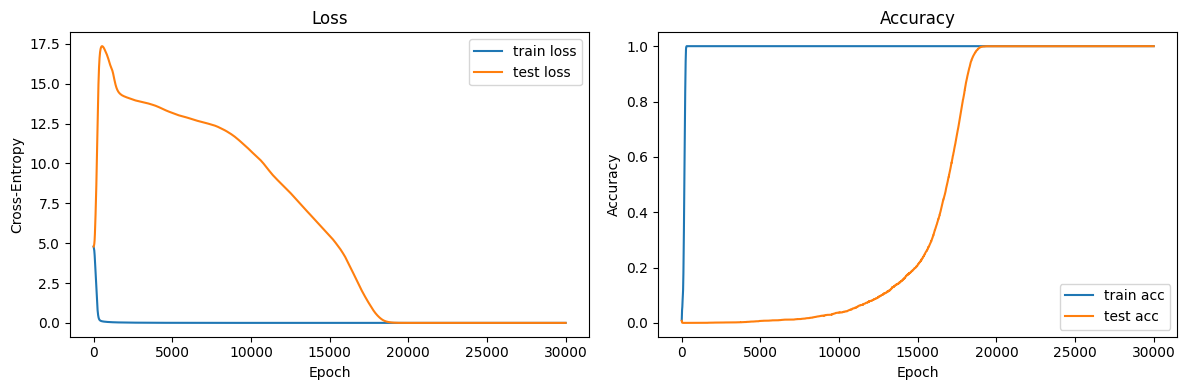

In [35]:
epochs_cpu2 = torch.arange(len(train_losses2)).cpu()
train_losses_cpu2 = train_losses2.detach().cpu()
test_losses_cpu2 = test_losses2.detach().cpu()
train_accs_cpu2 = train_accs2.detach().cpu()
test_accs_cpu2 = test_accs2.detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_cpu2, train_losses_cpu2, label="train loss")
axes[0].plot(epochs_cpu2, test_losses_cpu2, label="test loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

axes[1].plot(epochs_cpu2, train_accs_cpu2, label="train acc")
axes[1].plot(epochs_cpu2, test_accs_cpu2, label="test acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


# Tensor network example

Here I attempt to construct a similar 2-layer MLP modelling the operation of word recognition. This can be modelled as a tensor $T_{ijk}$ where the first two indices represent the input objects that I construct a word out of and the last one is the output object. 

Here I construct the dataset as in 2509.06931. The idea is that the data will be made out of triples of elements of a group encoded as one-hot vectors. One needs to choose a group to work this in and the operation. I will work initially with the permutation group as I have it implemented already. Then I will implement a function for the operation. 

I will initially choose the function $w(a,b)=a^2 b$. I already added this into the class definition of the permutation

In [19]:
grp=symmgr(4, device=device)
print(grp.idx_to_perm(5))
print(grp.idx_to_perm(grp.compose(5,5)))
print(grp.idx_to_perm(grp.square_times(5,grp.identity)))

(0 1 3 2)
(0 3)(1 2)
(0 3)(1 2)


In [3]:
def tensor_data(n: int, frac: float, device, pair_seed: int | None = None):
    grp=symmgr(n,device=device)

    idx = torch.arange(grp.order, device=device)
    pairs = torch.cartesian_prod(idx, idx)   # shape: (N, 2)

    y_idx = torch.tensor(
        [grp.square_times(i.item(), j.item()) for i, j in pairs],
        device=device,
        dtype=torch.long
    )

    # one-hot encode each element of the pair, then concatenate
    x1 = F.one_hot(pairs[:, 0], num_classes=grp.order).float()
    x2 = F.one_hot(pairs[:, 1], num_classes=grp.order).float()
    X = torch.cat([x1, x2], dim=1).to(torch.float32)   # shape: (N, 2*grp.order)

    # one-hot encode output
    Y = F.one_hot(y_idx, num_classes=grp.order).float() # shape: (N, grp.order)

    if pair_seed is None:
        perm = torch.randperm(grp.order*grp.order, device=device)
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed)
        perm = torch.randperm(grp.order*grp.order, generator=g, device=device)

    N=X.shape[0]
    N_train=int(frac*N)

    train_idx=perm[:N_train]
    test_idx=perm[N_train:]

    return {
        'X': X[perm],
        'Y': Y[perm],
        'Y_idx': y_idx[perm],
        'X_train': X[train_idx],
        'Y_train': Y[train_idx],
        'Y_train_idx': y_idx[train_idx],
        'X_test': X[test_idx],
        'Y_test': Y[test_idx],
        'Y_test_idx': y_idx[test_idx],
        'grp':grp,
    }
    

In [4]:
dat=tensor_data(4,0.3,device, pair_seed) #data saved as: input (n!^2,2*n!) and output (n!^2,n!)
print(dat['X'].shape)
print(dat['Y'].shape)

torch.Size([576, 48])
torch.Size([576, 24])


In [4]:
class TensorNet(nn.Module):
    def __init__(self, in_size, hid_size, out_size, activation='square', init_std=None, bias=False):
        super().__init__()
        
        self.in_size = int(in_size)
        self.out_size = int(out_size)
        self.hid_size = int(hid_size)
        self.activation_name = activation
        
        self.W1 = nn.Linear(self.in_size, self.hid_size, bias=bias)
        self.W2 = nn.Linear(self.hid_size, self.out_size, bias=bias)
        
        if init_std is None:
            init_std = 1.0 / math.sqrt(self.hid_size)
        
        nn.init.normal_(self.W1.weight, mean=0.0, std=init_std)
        nn.init.normal_(self.W2.weight, mean=0.0, std=init_std)
        
        if bias:
            nn.init.zeros_(self.W1.bias)
            nn.init.zeros_(self.W2.bias)

    def activation(self, x):
        if self.activation_name == 'square':
            return x * x
        if self.activation_name == 'relu':
            return F.relu(x)
        if self.activation_name == 'sigmoid':
            return torch.sigmoid(x)
        raise ValueError(f'Unknown activation: {self.activation_name}')

    def forward(self, x):
        return self.W2(self.activation(self.W1(x)))
           

In [6]:
n=4
frac = 0.8
hid_size = 250
in_size=2*math.factorial(n)
out_size=math.factorial(n)
# toggle between a quick sanity-check run and a slower paper-style run
run_mode = 'paper'   # 'debug' or 'paper'

if run_mode == 'debug':
    n_epochs = 10000
    batch_size = None   # full batch
    activation = 'sigmoid'
    lr = 5e-3
    weight_decay = 0.0
    init_std = 0.10
elif run_mode == 'paper':
    n_epochs = 5000
    batch_size = 16
    activation = 'sigmoid'
    lr = 5e-3
    weight_decay = 0.0
    init_std = 0.01
else:
    raise ValueError(f'Unknown run_mode: {run_mode}')


torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

data = tensor_data(n, frac, device, pair_seed)

modelTensor = TensorNet(in_size=in_size, hid_size=hid_size, out_size=out_size, activation=activation, init_std=init_std, bias=False).to(device)
criterion3 = nn.MSELoss()
optimizer3 = optim.AdamW(modelTensor.parameters(), lr=lr, weight_decay=weight_decay)


In [10]:
print(modelTensor.W1)
print(modelTensor.W2)

Linear(in_features=48, out_features=250, bias=False)
Linear(in_features=250, out_features=24, bias=False)


In [7]:
train_losses3 = torch.empty(n_epochs, device=device)
test_losses3 = torch.empty(n_epochs, device=device)
train_accs3 = torch.empty(n_epochs, device=device)
test_accs3 = torch.empty(n_epochs, device=device)

X_train = data['X_train'].float()
Y_train = data['Y_train'].float()
Y_train_idx = data['Y_train_idx'].long()
X_test = data['X_test'].float()
Y_test = data['Y_test'].float()
Y_test_idx = data['Y_test_idx'].long()

if batch_size is None:
    batch_size = X_train.shape[0]
    
train_ds = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

for epoch in range(n_epochs):
    modelTensor.train()

    for xb, yb in train_loader:
        optimizer3.zero_grad()
        logits = modelTensor(xb)
        loss = criterion3(logits, yb)
        loss.backward()
        optimizer3.step()

    modelTensor.eval()
    with torch.no_grad():
        train_logits = modelTensor(X_train)
        test_logits = modelTensor(X_test)

        train_loss = criterion3(train_logits, Y_train)
        test_loss = criterion3(test_logits, Y_test)

        train_pred = train_logits.argmax(dim=1)
        test_pred = test_logits.argmax(dim=1)

        train_acc = (train_pred == Y_train_idx).float().mean()
        test_acc = (test_pred == Y_test_idx).float().mean()

    train_losses3[epoch] = train_loss
    test_losses3[epoch] = test_loss
    train_accs3[epoch] = train_acc
    test_accs3[epoch] = test_acc

    if (epoch + 1) % 200 == 0:
        print(
            f"Epoch {epoch+1:6d}/{n_epochs} | "
            f"train_loss={train_loss.item():.6f} | "
            f"test_loss={test_loss.item():.6f} | "
            f"train_acc={train_acc.item():.6f} | "
            f"test_acc={test_acc.item():.6f}"
        )

Epoch    200/5000 | train_loss=0.000187 | test_loss=0.014070 | train_acc=1.000000 | test_acc=0.862069
Epoch    400/5000 | train_loss=0.000255 | test_loss=0.012346 | train_acc=1.000000 | test_acc=0.896552
Epoch    600/5000 | train_loss=0.000261 | test_loss=0.011529 | train_acc=1.000000 | test_acc=0.922414
Epoch    800/5000 | train_loss=0.000099 | test_loss=0.010516 | train_acc=1.000000 | test_acc=0.922414
Epoch   1000/5000 | train_loss=0.000118 | test_loss=0.009993 | train_acc=1.000000 | test_acc=0.931035
Epoch   1200/5000 | train_loss=0.000131 | test_loss=0.009458 | train_acc=1.000000 | test_acc=0.956897
Epoch   1400/5000 | train_loss=0.000123 | test_loss=0.009074 | train_acc=1.000000 | test_acc=0.965517
Epoch   1600/5000 | train_loss=0.000075 | test_loss=0.008529 | train_acc=1.000000 | test_acc=0.974138
Epoch   1800/5000 | train_loss=0.000087 | test_loss=0.008495 | train_acc=1.000000 | test_acc=0.974138
Epoch   2000/5000 | train_loss=0.000080 | test_loss=0.008205 | train_acc=1.000000 

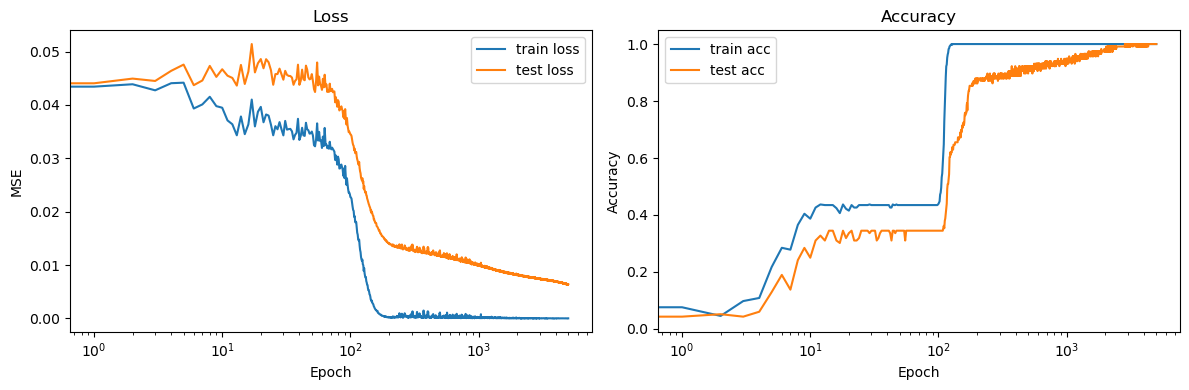

In [8]:
epochs_cpu3 = torch.arange(len(train_losses3)).cpu()
train_losses_cpu3 = train_losses3.detach().cpu()
test_losses_cpu3 = test_losses3.detach().cpu()
train_accs_cpu3 = train_accs3.detach().cpu()
test_accs_cpu3 = test_accs3.detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_xscale('log')
axes[0].plot(epochs_cpu3, train_losses_cpu3, label="train loss")
axes[0].plot(epochs_cpu3, test_losses_cpu3, label="test loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].set_xscale('log')
axes[1].plot(epochs_cpu3, train_accs_cpu3, label="train acc")
axes[1].plot(epochs_cpu3, test_accs_cpu3, label="test acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()
